In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

1. Load Iris dataset

In [ ]:
iris = load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [ ]:
X, y = iris.data, iris.target

2. Split data into training and testing datasets

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

3. Create and train k-NN classifier

In [12]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

4. Test and Calculate Accuracy

In [14]:
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {100 * accuracy:.4f}%")
print(f"Species mapping: {dict(enumerate(iris.target_names))}")

Model Accuracy: 100.0000%
Species mapping: {0: np.str_('setosa'), 1: np.str_('versicolor'), 2: np.str_('virginica')}


5. Plot the train and test data for better presentation

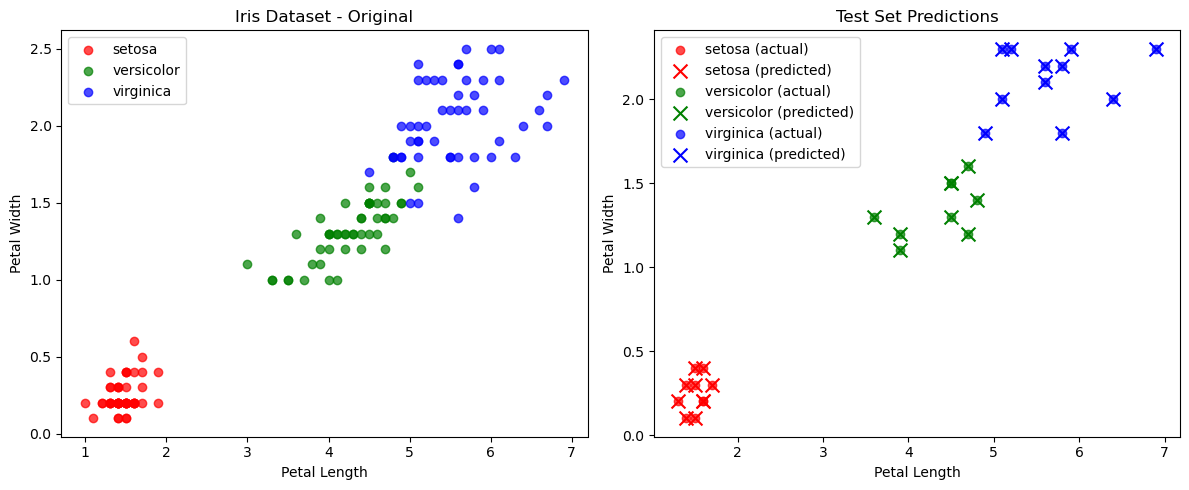

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Original data
colors = ['red', 'green', 'blue']
for i, species in enumerate(iris.target_names):
    mask = y == i
    ax1.scatter(X[mask, 2], X[mask, 3], c=colors[i], label=species, alpha=0.7)
ax1.set_xlabel('Petal Length')
ax1.set_ylabel('Petal Width')
ax1.set_title('Iris Dataset - Original')
ax1.legend()

# Plot 2: Test predictions
for i, species in enumerate(iris.target_names):
    mask = y_test == i
    ax2.scatter(X_test[mask, 2], X_test[mask, 3], c=colors[i], label=f'{species} (actual)', alpha=0.7)
    mask_pred = y_pred == i
    ax2.scatter(X_test[mask_pred, 2], X_test[mask_pred, 3], c=colors[i], marker='x', s=100, label=f'{species} (predicted)')
ax2.set_xlabel('Petal Length')
ax2.set_ylabel('Petal Width')
ax2.set_title('Test Set Predictions')
ax2.legend()

plt.tight_layout()
plt.show()